# Build a Texas FEMA eBFE Breakout from Adjacent Main-Stem Models

This notebook uses two real Lower Colorado–Cummins FEMA Base Level Engineering
(eBFE) projects and one real NOAA National Water Model v3 flowline. **NWM
feature 5790954** crosses the boundary between consecutive Walnut Creek
main-stem models `WALNUT 0230` and `WALNUT 0229`.

The objective is to plan, write, and visually verify one independent 1D
breakout without hiding the cross-model join:

1. Catalog independent steady 1D projects in GeoParquet-ready tables.
2. Use model polygons to find extent candidates.
3. Confirm the corresponding RAS reach with cross-section intersections,
   station sequence, and a transparent centerline-offset limit.
4. Find the minimum-switch source chain along the directed network edge.
5. Reject source pairs when multiple cross sections intersect both centerlines.
6. Write the joined river line and complete retained geometry blocks.
7. Restation every retained node, recompute main-channel lengths, and rewrite
   steady-flow locations and boundary references.
8. Show the larger computational domain, strict inundation domain, resolved
   join, and source-to-destination station map.

The committed figures are visual evidence from the real Texas/FEMA geometries.
Notebook 235 demonstrates the complementary single-source operation: it writes,
runs, and compares a buffered breakout while preserving a stricter one-section-
overlap inundation export domain.


In [1]:
from datetime import datetime
from pathlib import Path
import io
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
import pandas as pd
import requests
from IPython.display import display
from shapely.ops import nearest_points, substring


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ras_commander
from ras_commander import (
    GeomCrossSection,
    GeomParser,
    HdfResultsPlan,
    RasBreakout1D,
    RasCmdr,
    RasGeometryCompute,
    RasPrj,
    init_ras_project,
)

WORK_ROOT = REPO_ROOT / "working" / "236_multi_model_1d_breakout_planning"
RUN_ROOT = WORK_ROOT / "runs" / datetime.now().strftime("%Y%m%d_%H%M%S")
ASSET_ROOT = REPO_ROOT / "examples" / "assets" / "236_multi_model_1d_breakout_planning"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT.mkdir(parents=True, exist_ok=False)
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

EBFE_MODEL_ROOT = Path(
    os.environ.get(
        "RAS_COMMANDER_EBFE_RAW_MODEL_ROOT",
        "H:/Testing/eBFE Model Organization/Downloads/12090301_Models_extracted/Model",
    )
)
SOURCE_GROUP = EBFE_MODEL_ROOT / "Walnut Creek-Colorado River"
SOURCE_IDS = ("WALNUT 0230", "WALNUT 0229")
TARGET_EDGE_ID = "5790954"
PROJECT_CRS = "EPSG:2277"  # NAD83 / Texas Central (ftUS)
RAS_VERSION = "7.0.1"
MAX_CENTERLINE_OFFSET_FT = 500.0
MAX_CROSS_CENTERLINE_XS = 1

print(f"ras-commander: {ras_commander.__version__}")
print(f"Loaded from: {ras_commander.__file__}")
print(f"eBFE source group: {SOURCE_GROUP}")
print(f"Isolated run root: {RUN_ROOT}")


ras-commander: 0.99.2
Loaded from: H:\Symphony\ras-commander\multi-model-breakout\ras_commander\__init__.py
eBFE source group: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Walnut Creek-Colorado River
Isolated run root: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616


## 1. Build a source catalog—not a database

Each caller-defined source ID is attached to an independent `RasPrj`. The
catalog records the active plan, geometry and flow files, profile schema,
geometry hash, footprint, river centerline, and cross-section cut lines.

These 4.1-era projects have no RASMapper file or CRS in their geometry HDF, so
the documented Texas Central feet CRS is supplied explicitly. The fallback
footprint is the convex hull of the text geometry's centerline and cut lines.
The persisted catalog uses Parquet/GeoParquet rather than GeoPackage or SQLite.


In [2]:
source_models = {}
for source_id in SOURCE_IDS:
    model_folder = SOURCE_GROUP / source_id
    project_file = model_folder / f"{source_id}.prj"
    if not project_file.is_file():
        raise FileNotFoundError(
            f"Missing {project_file}. Set RAS_COMMANDER_EBFE_RAW_MODEL_ROOT "
            "to the extracted Lower Colorado-Cummins Model root."
        )
    ras = RasPrj()
    init_ras_project(
        project_file,
        RAS_VERSION,
        ras_object=ras,
        hide_intro=True,
    )
    source_models[source_id] = ras

catalog = RasBreakout1D.catalog_sources(
    source_models,
    analysis_crs=PROJECT_CRS,
)
catalog_path = catalog.write(WORK_ROOT / "source_catalog", overwrite=True)

assert catalog.summary == {
    "source_models": 2,
    "included_models": 2,
    "duplicate_models": 0,
    "reaches": 2,
    "cross_sections": 86,
}
display(pd.DataFrame([catalog.summary]))
display(
    catalog.models_df[[
        "geometry_id", "plan_number", "profile_count", "profile_names",
        "geometry_sha256", "included",
    ]]
)
print(f"GeoParquet catalog: {catalog_path}")


2026-09-09 09:26:16 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Walnut Creek-Colorado River\WALNUT 0230\WALNUT 0230.rasmap


2026-09-09 09:26:16 - ras_commander.RasPrj - WARNING - Could not resolve project CRS for WALNUT 0230


2026-09-09 09:26:16 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Walnut Creek-Colorado River\WALNUT 0229\WALNUT 0229.rasmap


2026-09-09 09:26:16 - ras_commander.RasPrj - WARNING - Could not resolve project CRS for WALNUT 0229


,source_models,included_models,duplicate_models,reaches,cross_sections
0,2,2,0,2,86


,geometry_id,plan_number,profile_count,profile_names,geometry_sha256,included
0,WALNUT 0229,01,7,"(10-year, 25-year, 50-year, 1pct_min, 100-year...",d03853517dca50a904df7f7db018ebae36bc7a7b3be5c2...,True
1,WALNUT 0230,01,7,"(10-year, 25-year, 50-year, 1pct_min, 100-year...",a2a065658c2ea25e0611487da0e1f00b0bd056f7cf3b19...,True


GeoParquet catalog: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\source_catalog


## 2. Plan directed coverage for the real NWM edge

The NOAA service returns the target flowline directly. Its coordinate order is
treated as upstream to downstream. Model polygons are only the candidate
filter; a source is accepted only when one reach has at least two intersecting
cross sections, decreasing RAS stations advance with edge measure, and its
sampled mean centerline offset is no more than 500 feet.

The handoff then fails closed if more than one source cross section intersects
both selected centerlines. This explicit check rejects the former tributary/
main-stem example. The adjacent Walnut segments have zero such cross sections.


In [3]:
NWM_SERVICE = (
    "https://maps.water.noaa.gov/server/rest/services/"
    "reference/static_nwm_flowlines/FeatureServer/0/query"
)
nwm_cache = WORK_ROOT / f"nwm_{TARGET_EDGE_ID}.parquet"
if nwm_cache.is_file():
    target_edge = gpd.read_parquet(nwm_cache)
else:
    query = {
        "where": f"feature_id={TARGET_EDGE_ID}",
        "outFields": "feature_id,name,strm_order,huc6,nwm_vers",
        "returnGeometry": "true",
        "outSR": 4326,
        "f": "geojson",
    }
    response = requests.get(NWM_SERVICE, params=query, timeout=60)
    response.raise_for_status()
    target_edge = gpd.read_file(io.BytesIO(response.content))
    target_edge["feature_id"] = target_edge["feature_id"].astype(str)
    target_edge.to_parquet(nwm_cache, index=False)
target_edge = target_edge.to_crs(PROJECT_CRS)
assert target_edge["feature_id"].astype(str).eq(TARGET_EDGE_ID).all()

plan = RasBreakout1D.plan_network_edge(
    catalog,
    target_edge,
    edge_id=TARGET_EDGE_ID,
    adapter="nwm",
    max_centerline_offset=MAX_CENTERLINE_OFFSET_FT,
    max_cross_centerline_xs=MAX_CROSS_CENTERLINE_XS,
)

plan_row = plan.coverage_plan.plans_df.iloc[0]
assert plan.status == "multi_source_ready"
assert plan_row["source_geometry_ids"] == SOURCE_IDS
assert plan_row["coverage_fraction"] == 1.0
assert plan.seams_df.iloc[0]["relationship"] == "overlap"
assert plan.join_ready
assert plan.handoff_diagnostics_df.iloc[0]["cross_centerline_xs_count"] == 0
assert plan.handoff_diagnostics_df.iloc[0]["handoff_eligible"]

display(
    plan.reach_assignments_df.drop(columns="geometry").style.format({
        "xs_measure_start": "{:.0f}",
        "xs_measure_end": "{:.0f}",
        "centerline_offset_mean": "{:.1f}",
    })
)
display(plan.coverage_plan.plans_df.drop(columns="geometry"))
display(plan.source_slices_df.drop(columns="geometry"))
display(plan.seams_df.drop(columns="geometry"))
display(plan.handoff_diagnostics_df.drop(columns="geometry"))


,geometry_id,edge_id,reach_id,river,reach,xs_intersection_count,xs_measure_start,xs_measure_end,xs_sequence,centerline_offset_mean,status,reason_codes
0,WALNUT 0229,5790954,WALNUT 0229::WALNUT 0229::Reach-1,WALNUT 0229,Reach-1,62,5305,35416,with_edge,185.6,confirmed,()
1,WALNUT 0230,5790954,WALNUT 0230::WALNUT 0230::Reach-1,WALNUT 0230,Reach-1,10,1203,4884,with_edge,35.0,confirmed,()


,edge_id,status,edge_length,selected_model_count,selected_slice_count,source_geometry_ids,source_slice_geometry_ids,covered_length,coverage_fraction,total_gap_length,maximum_gap_length,fully_covered,orientation_source
0,5790954,multi_source_ready,35819.279831,2,2,"(WALNUT 0230, WALNUT 0229)","(WALNUT 0230, WALNUT 0229)",35819.279831,1.0,0.0,0.0,True,edge_coordinate_order


,edge_id,source_order,geometry_id,coverage_start,coverage_end,retained_start,retained_end,retained_length
0,5790954,0,WALNUT 0230,0.000000,5137.026129,0.000000,4634.187189,4634.187189
1,5790954,1,WALNUT 0229,4131.348249,35819.279831,4634.187189,35819.279831,31185.092642


,edge_id,seam_index,upstream_geometry_id,downstream_geometry_id,relationship,overlap_start,overlap_end,overlap_length,gap_length,seam_measure,seam_fraction
0,5790954,0,WALNUT 0230,WALNUT 0229,overlap,4131.348249,5137.026129,1005.67788,0.0,4634.187189,0.129377


,edge_id,seam_index,upstream_geometry_id,downstream_geometry_id,upstream_reach_id,downstream_reach_id,centerline_distance,centerline_intersects,upstream_xs_intersect_both_count,downstream_xs_intersect_both_count,upstream_xs_intersect_both_ids,downstream_xs_intersect_both_ids,cross_centerline_xs_count,cross_centerline_xs_ids,max_cross_centerline_xs,handoff_eligible,reason_codes
0,5790954,0,WALNUT 0230,WALNUT 0229,WALNUT 0230::WALNUT 0230::Reach-1,WALNUT 0229::WALNUT 0229::Reach-1,0.0,True,0,0,(),(),0,(),1,True,()


## 3. Visual proof: extents find candidates; geometry confirms them

The first panel shows why the two model polygons are sufficient for coverage
measurement. The second panel supplies the hydraulic evidence: independently
parsed RAS centerlines and cross-section cut lines continue along the same main
stem. The magenta star is the midpoint of the shared **footprint** interval;
the green diamond is the actual source-centerline intersection.


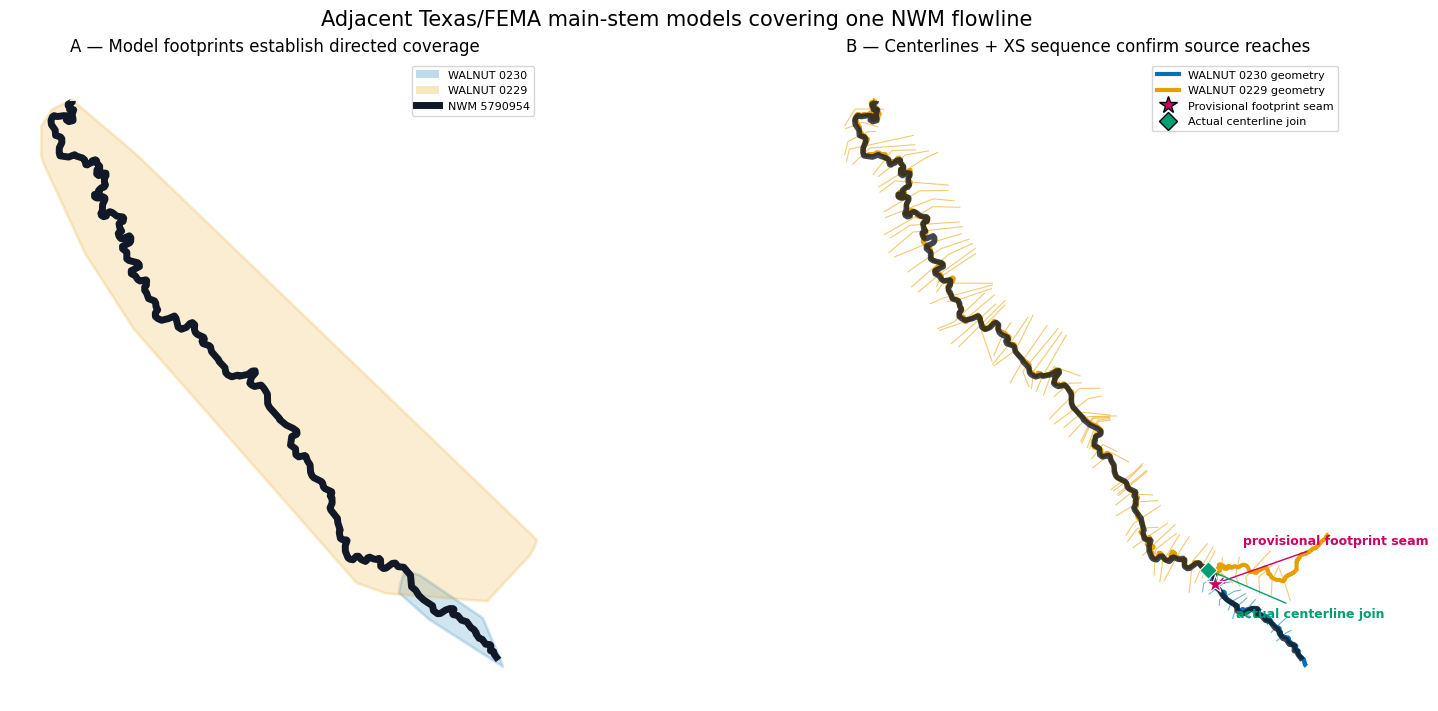

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\01_extent_and_geometry_confirmation.png


In [4]:
colors = {
    "WALNUT 0230": "#0072B2",
    "WALNUT 0229": "#E69F00",
}
edge_geometry = target_edge.geometry.iloc[0]
seam = plan.seams_df.iloc[0]
focus = edge_geometry.buffer(1400.0)

confirmed = plan.reach_assignments_df.loc[
    plan.reach_assignments_df["status"] == "confirmed"
]
confirmed_reach_ids = set(confirmed["reach_id"])
confirmed_centerlines = catalog.centerlines_gdf.loc[
    catalog.centerlines_gdf["reach_id"].isin(confirmed_reach_ids)
]
confirmed_xs = catalog.cross_sections_gdf.loc[
    catalog.cross_sections_gdf["reach_id"].isin(confirmed_reach_ids)
    & catalog.cross_sections_gdf.intersects(focus)
]
centerline_by_source = confirmed.set_index("geometry_id").geometry
centerline_join = centerline_by_source.loc[SOURCE_IDS[0]].intersection(
    centerline_by_source.loc[SOURCE_IDS[1]]
)
assert centerline_join.geom_type == "Point"
edge_join_point, _ = nearest_points(edge_geometry, centerline_join)
join_measure = float(edge_geometry.project(edge_join_point))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
for source_id in SOURCE_IDS:
    footprint = catalog.footprints_gdf.loc[
        catalog.footprints_gdf["geometry_id"] == source_id
    ]
    footprint.plot(
        ax=axes[0], color=colors[source_id], edgecolor=colors[source_id],
        alpha=0.18, linewidth=2,
    )
target_edge.plot(ax=axes[0], color="#111827", linewidth=5)

for source_id in SOURCE_IDS:
    confirmed_centerlines.loc[
        confirmed_centerlines["geometry_id"] == source_id
    ].plot(ax=axes[1], color=colors[source_id], linewidth=3)
    confirmed_xs.loc[
        confirmed_xs["geometry_id"] == source_id
    ].plot(ax=axes[1], color=colors[source_id], linewidth=0.8, alpha=0.55)
target_edge.plot(ax=axes[1], color="#111827", linewidth=4, alpha=0.8)
plan.seams_df.plot(
    ax=axes[1], color="#CC0066", marker="*", markersize=180,
    edgecolor="white", linewidth=0.8, zorder=10,
)
gpd.GeoSeries([centerline_join], crs=PROJECT_CRS).plot(
    ax=axes[1], color="#009E73", marker="D", markersize=80,
    edgecolor="white", linewidth=0.8, zorder=11,
)

for ax in axes:
    xmin, ymin, xmax, ymax = focus.bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
axes[0].set_title("A — Model footprints establish directed coverage")
axes[1].set_title("B — Centerlines + XS sequence confirm source reaches")
axes[1].annotate(
    "provisional footprint seam",
    (seam.geometry.x, seam.geometry.y),
    xytext=(20, 28), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#CC0066"},
    color="#CC0066", fontsize=9, fontweight="bold",
)
axes[1].annotate(
    "actual centerline join",
    (centerline_join.x, centerline_join.y),
    xytext=(20, -34), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#009E73"},
    color="#009E73", fontsize=9, fontweight="bold",
)
axes[0].legend(
    handles=[
        Patch(facecolor=colors[source_id], alpha=0.25, label=source_id)
        for source_id in SOURCE_IDS
    ] + [Line2D([0], [0], color="#111827", linewidth=5, label=f"NWM {TARGET_EDGE_ID}")],
    loc="best", fontsize=8,
)
axes[1].legend(
    handles=[
        Line2D([0], [0], color=colors[source_id], linewidth=3, label=f"{source_id} geometry")
        for source_id in SOURCE_IDS
    ] + [
        Line2D([0], [0], marker="*", color="none", markerfacecolor="#CC0066", markersize=13, label="Provisional footprint seam"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="#009E73", markersize=9, label="Actual centerline join"),
    ],
    loc="best", fontsize=8,
)
fig.suptitle("Adjacent Texas/FEMA main-stem models covering one NWM flowline", fontsize=15)
figure_1 = ASSET_ROOT / "01_extent_and_geometry_confirmation.png"
fig.savefig(figure_1, dpi=180, bbox_inches="tight")
plt.show()
print(figure_1)


![Real Texas/FEMA source footprints and hydraulic geometry confirmation](assets/236_multi_model_1d_breakout_planning/01_extent_and_geometry_confirmation.png)

## 4. Visual proof: the minimum-switch coverage chain

The upper ribbons show where each footprint covers the NWM edge. Their 1,006-ft
shared interval is a handoff search zone—not a reason to score seven unrelated
signals. The lower ribbon is the deterministic ownership plan: upstream source
until the midpoint, downstream source afterward. No coverage gap is hidden.


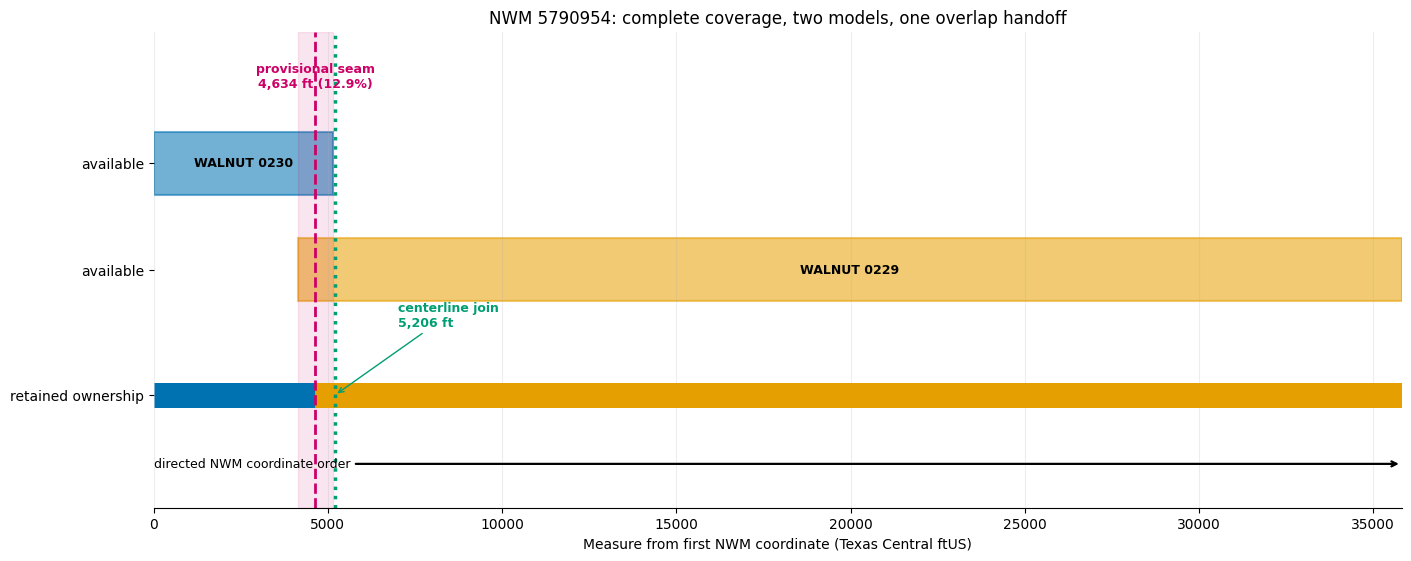

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\02_directed_coverage_chain.png


In [5]:
parts = plan.edge_coverage.coverage_parts_df.sort_values("coverage_start")
slices = plan.source_slices_df.sort_values("source_order")
edge_length = float(plan_row["edge_length"])
seam_measure = float(seam["seam_measure"])

fig, ax = plt.subplots(figsize=(14, 5.5), constrained_layout=True)
source_y = {SOURCE_IDS[0]: 2.2, SOURCE_IDS[1]: 1.35}
for row in parts.itertuples(index=False):
    ax.add_patch(Rectangle(
        (row.coverage_start, source_y[row.geometry_id] - 0.25),
        row.coverage_end - row.coverage_start, 0.5,
        facecolor=colors[row.geometry_id], alpha=0.55,
        edgecolor=colors[row.geometry_id], linewidth=1.5,
    ))
    ax.text(
        (row.coverage_start + row.coverage_end) / 2,
        source_y[row.geometry_id], row.geometry_id,
        ha="center", va="center", fontsize=9, fontweight="bold",
    )

overlap_start = float(seam["overlap_start"])
overlap_end = float(seam["overlap_end"])
ax.axvspan(overlap_start, overlap_end, color="#CC0066", alpha=0.10)
for row in slices.itertuples(index=False):
    ax.plot(
        [row.retained_start, row.retained_end], [0.35, 0.35],
        color=colors[row.geometry_id], linewidth=18, solid_capstyle="butt",
    )
ax.axvline(seam_measure, color="#CC0066", linestyle="--", linewidth=2)
ax.axvline(join_measure, color="#009E73", linestyle=":", linewidth=2.5)
ax.text(
    seam_measure, 2.78,
    f"provisional seam\n{seam_measure:,.0f} ft ({seam.seam_fraction:.1%})",
    ha="center", va="bottom", color="#CC0066", fontsize=9, fontweight="bold",
)
ax.annotate(
    f"centerline join\n{join_measure:,.0f} ft",
    xy=(join_measure, 0.35), xytext=(join_measure + 1800, 0.9),
    arrowprops={"arrowstyle": "->", "color": "#009E73"},
    color="#009E73", fontsize=9, fontweight="bold",
)
ax.annotate(
    "directed NWM coordinate order",
    xy=(edge_length, -0.2), xytext=(0, -0.2),
    arrowprops={"arrowstyle": "->", "linewidth": 1.6},
    va="center", fontsize=9,
)
ax.set_xlim(0, edge_length)
ax.set_ylim(-0.55, 3.25)
ax.set_yticks([2.2, 1.35, 0.35])
ax.set_yticklabels(["available", "available", "retained ownership"])
ax.set_xlabel("Measure from first NWM coordinate (Texas Central ftUS)")
ax.set_title(
    f"NWM {TARGET_EDGE_ID}: complete coverage, two models, one overlap handoff"
)
ax.grid(axis="x", alpha=0.22)
for side in ("left", "right", "top"):
    ax.spines[side].set_visible(False)
figure_2 = ASSET_ROOT / "02_directed_coverage_chain.png"
fig.savefig(figure_2, dpi=180, bbox_inches="tight")
plt.show()
print(figure_2)


![Directed model coverage intervals and provisional handoff](assets/236_multi_model_1d_breakout_planning/02_directed_coverage_chain.png)

## 5. Visual proof: a clean main-stem handoff

This final map projects directly intersecting cross sections onto the NWM edge.
The actual centerline intersection lies between the last upstream-model cross
section and the first downstream-model cross section. No source cross section
intersects both centerlines, and the two source cross-section sets do not cross
one another. That is the adjacent-main-stem condition needed for the writer.


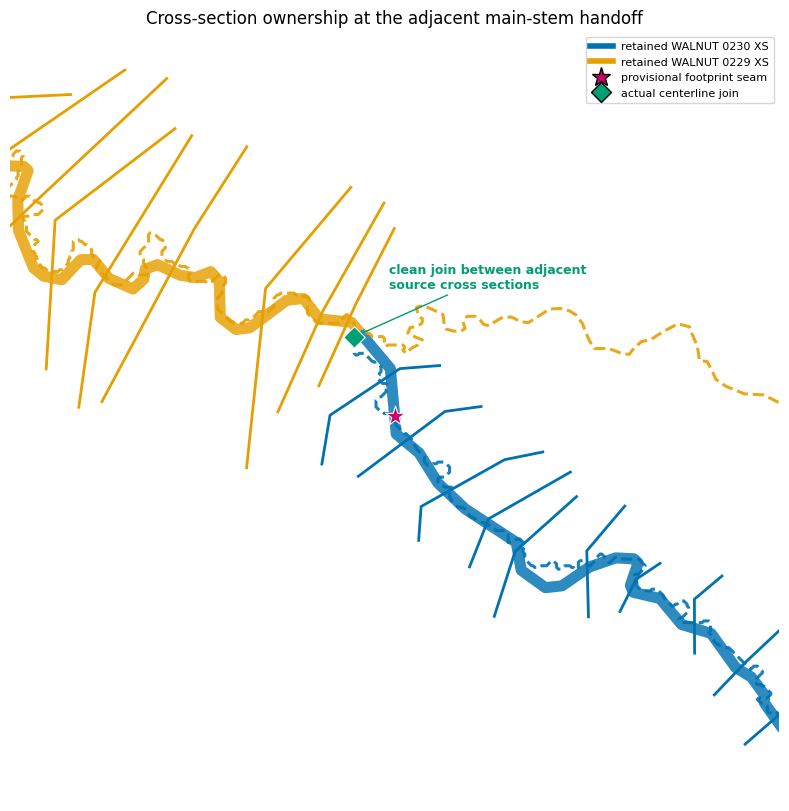

,geometry_id,station,edge_measure,retained_side
8,WALNUT 0230,5159,1203,True
7,WALNUT 0230,4510,1583,True
5,WALNUT 0230,4041,1959,True
4,WALNUT 0230,3396,2431,True
3,WALNUT 0230,2815,2919,True
2,WALNUT 0230,2199,3506,True
1,WALNUT 0230,1880,3758,True
0,WALNUT 0230,1522,4062,True
9,WALNUT 0230,918,4460,True
6,WALNUT 0230,405,4884,True


Centerline join measure: 5,206 ft
Cross sections intersecting both centerlines: 0
Pairwise source cross-section intersections: 0
H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\03_cross_section_ownership.png


In [6]:
assignment_by_source = confirmed.set_index("geometry_id")
xs_measure_rows = []
source_xs_by_id = {}
for source_id in SOURCE_IDS:
    reach_id = assignment_by_source.loc[source_id, "reach_id"]
    all_source_xs = catalog.cross_sections_gdf.loc[
        catalog.cross_sections_gdf["reach_id"] == reach_id
    ].copy()
    source_xs_by_id[source_id] = all_source_xs
    source_xs = all_source_xs.loc[
        all_source_xs.intersects(edge_geometry)
    ].copy()
    for row in source_xs.itertuples(index=False):
        edge_point, _ = nearest_points(edge_geometry, row.geometry)
        measure = float(edge_geometry.project(edge_point))
        retained = (
            measure <= join_measure
            if source_id == SOURCE_IDS[0]
            else measure >= join_measure
        )
        xs_measure_rows.append({
            "geometry_id": source_id,
            "station": row.station,
            "edge_measure": measure,
            "retained_side": retained,
            "geometry": row.geometry,
        })
xs_ownership = gpd.GeoDataFrame(
    xs_measure_rows, geometry="geometry", crs=PROJECT_CRS
).sort_values(["edge_measure", "geometry_id"])
pairwise_xs_intersections = sum(
    int(source_xs_by_id[SOURCE_IDS[1]].intersects(xs_geometry).sum())
    for xs_geometry in source_xs_by_id[SOURCE_IDS[0]].geometry
)
assert pairwise_xs_intersections == 0

fig, ax = plt.subplots(figsize=(12.5, 8), constrained_layout=True)
actual_ownership = (
    (SOURCE_IDS[0], substring(edge_geometry, 0.0, join_measure)),
    (SOURCE_IDS[1], substring(edge_geometry, join_measure, edge_geometry.length)),
)
for source_id, geometry in actual_ownership:
    gpd.GeoSeries([geometry], crs=PROJECT_CRS).plot(
        ax=ax, color=colors[source_id], linewidth=8, alpha=0.82,
    )
for source_id in SOURCE_IDS:
    centerline = confirmed_centerlines.loc[
        confirmed_centerlines["geometry_id"] == source_id
    ]
    centerline.plot(
        ax=ax, color=colors[source_id], linewidth=2.2, linestyle="--", alpha=0.9,
    )
    xs_ownership.loc[
        (xs_ownership["geometry_id"] == source_id)
        & xs_ownership["retained_side"]
    ].plot(ax=ax, color=colors[source_id], linewidth=2.0)
excluded_xs = xs_ownership.loc[~xs_ownership["retained_side"]]
if not excluded_xs.empty:
    excluded_xs.plot(
        ax=ax, color="#6B7280", linewidth=1.4, linestyle=":", alpha=0.9,
    )
plan.seams_df.plot(
    ax=ax, color="#CC0066", marker="*", markersize=220,
    edgecolor="white", linewidth=0.8, zorder=10,
)
gpd.GeoSeries([centerline_join], crs=PROJECT_CRS).plot(
    ax=ax, color="#009E73", marker="D", markersize=120,
    edgecolor="white", linewidth=0.8, zorder=11,
)
seam_focus = seam.geometry.buffer(2300.0)
xmin, ymin, xmax, ymax = seam_focus.bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Cross-section ownership at the adjacent main-stem handoff")
ax.legend(
    handles=[
        Line2D([0], [0], color=colors[SOURCE_IDS[0]], linewidth=4, label=f"retained {SOURCE_IDS[0]} XS"),
        Line2D([0], [0], color=colors[SOURCE_IDS[1]], linewidth=4, label=f"retained {SOURCE_IDS[1]} XS"),
        Line2D([0], [0], marker="*", color="none", markerfacecolor="#CC0066", markersize=14, label="provisional footprint seam"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="#009E73", markersize=10, label="actual centerline join"),
    ],
    loc="best", fontsize=8,
)
ax.annotate(
    "clean join between adjacent\nsource cross sections",
    (centerline_join.x, centerline_join.y),
    xytext=(25, 35), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#009E73"},
    color="#009E73", fontsize=9, fontweight="bold",
)
figure_3 = ASSET_ROOT / "03_cross_section_ownership.png"
fig.savefig(figure_3, dpi=180, bbox_inches="tight")
plt.show()

display(
    xs_ownership.drop(columns="geometry").style.format({"edge_measure": "{:.0f}"})
)
print(f"Centerline join measure: {join_measure:,.0f} ft")
print(f"Cross sections intersecting both centerlines: {int(plan.handoff_diagnostics_df.iloc[0]['cross_centerline_xs_count'])}")
print(f"Pairwise source cross-section intersections: {pairwise_xs_intersections}")
print(figure_3)


## 6. Visual proof: reach-length evidence before geometry assembly

Channel and overbank distances answer different questions. The channel audit
compares each stored channel length with the distance between adjacent cut-line
intersections measured along the RAS river polyline. The overbank panel shows
whether stored LOB/ROB values already carry routing evidence distinct from the
channel. Neither check changes the FEMA sources.

These legacy text geometries contain no compiled geometry HDF, so they cannot
yet prove that regenerated RAS Mapper flow paths reproduce the stored values.
That test belongs on the provisional joined geometry and is shown after the
figure.


,geometry_id,channel_intervals,max_channel_error_percent,channel_all_within_1pct,stored_overbanks_distinct,compiled_geometry_hdf_exists,flow_path_preflight
0,WALNUT 0230,9,0.120%,True,False,False,clone_and_regenerate_required
1,WALNUT 0229,75,1.815%,False,False,False,clone_and_regenerate_required


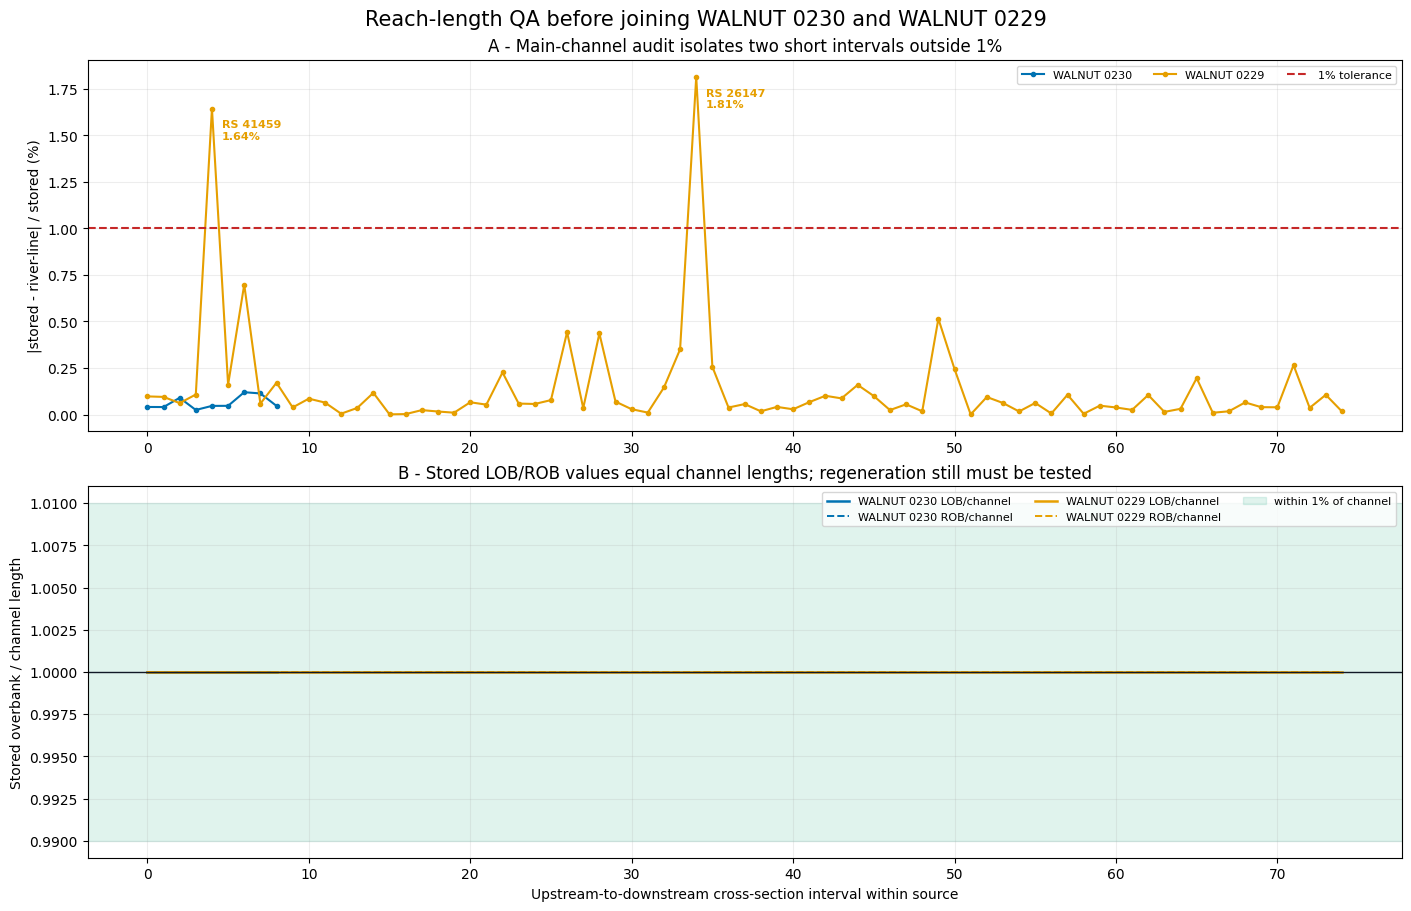

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\04_reach_length_policy_evidence.png


In [7]:
channel_frames = []
overbank_frames = []
policy_rows = []
model_paths = catalog.models_df.set_index("geometry_id")["geometry_path"]

for source_id in SOURCE_IDS:
    geometry_path = Path(model_paths.loc[source_id])
    channel = RasGeometryCompute.audit_main_channel_lengths(
        geometry_path, tolerance_fraction=0.01
    ).copy()
    channel["geometry_id"] = source_id
    channel["interval_order"] = range(len(channel))
    channel_frames.append(channel)

    stored = GeomCrossSection.get_cross_sections(geometry_path)
    stored = stored.loc[stored["Type"] == 1].copy()
    usable = stored["Length_Channel"].abs() > 1.0e-9
    stored = stored.loc[usable].copy()
    stored["geometry_id"] = source_id
    stored["interval_order"] = range(len(stored))
    stored["left_channel_ratio"] = (
        stored["Length_Left"] / stored["Length_Channel"]
    )
    stored["right_channel_ratio"] = (
        stored["Length_Right"] / stored["Length_Channel"]
    )
    overbank_frames.append(stored)

    overbanks_distinct = bool(
        ((stored["left_channel_ratio"] - 1.0).abs() > 0.01).any()
        or ((stored["right_channel_ratio"] - 1.0).abs() > 0.01).any()
    )
    compiled_hdf = Path(f"{geometry_path}.hdf")
    preflight = (
        "preserve_and_recompute_only_at_join_boundary"
        if not compiled_hdf.is_file() and overbanks_distinct
        else "clone_and_regenerate_required"
    )
    usable_channel = channel.loc[~channel["reach_end"]]
    policy_rows.append({
        "geometry_id": source_id,
        "channel_intervals": len(usable_channel),
        "max_channel_error_percent": 100.0 * usable_channel["relative_error_channel"].max(),
        "channel_all_within_1pct": not usable_channel["main_channel_flagged"].any(),
        "stored_overbanks_distinct": overbanks_distinct,
        "compiled_geometry_hdf_exists": compiled_hdf.is_file(),
        "flow_path_preflight": preflight,
    })

channel_evidence = pd.concat(channel_frames, ignore_index=True)
overbank_evidence = pd.concat(overbank_frames, ignore_index=True)
policy_preflight = pd.DataFrame(policy_rows)
display(policy_preflight.style.format({"max_channel_error_percent": "{:.3f}%"}))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
for source_id in SOURCE_IDS:
    channel = channel_evidence.loc[
        (channel_evidence["geometry_id"] == source_id)
        & ~channel_evidence["reach_end"]
    ]
    axes[0].plot(
        channel["interval_order"],
        100.0 * channel["relative_error_channel"],
        marker="o", markersize=3, linewidth=1.5,
        color=colors[source_id], label=source_id,
    )
    for flagged in channel.loc[channel["main_channel_flagged"]].itertuples(index=False):
        error_percent = 100.0 * flagged.relative_error_channel
        axes[0].annotate(
            f"RS {flagged.RS}\n{error_percent:.2f}%",
            (flagged.interval_order, error_percent),
            xytext=(7, -8), textcoords="offset points", va="top",
            color=colors[source_id], fontsize=8, fontweight="bold",
        )
    overbank = overbank_evidence.loc[
        overbank_evidence["geometry_id"] == source_id
    ]
    axes[1].plot(
        overbank["interval_order"], overbank["left_channel_ratio"],
        color=colors[source_id], linewidth=1.8, label=f"{source_id} LOB/channel",
    )
    axes[1].plot(
        overbank["interval_order"], overbank["right_channel_ratio"],
        color=colors[source_id], linewidth=1.4, linestyle="--",
        label=f"{source_id} ROB/channel",
    )

axes[0].axhline(1.0, color="#C62828", linestyle="--", linewidth=1.5, label="1% tolerance")
axes[0].set_ylabel("|stored - river-line| / stored (%)")
axes[0].set_title("A - Main-channel audit isolates two short intervals outside 1%")
axes[0].legend(fontsize=8, ncol=3)
axes[0].grid(alpha=0.22)

axes[1].axhspan(0.99, 1.01, color="#009E73", alpha=0.12, label="within 1% of channel")
axes[1].axhline(1.0, color="#111827", linewidth=1.0)
axes[1].set_xlabel("Upstream-to-downstream cross-section interval within source")
axes[1].set_ylabel("Stored overbank / channel length")
axes[1].set_title("B - Stored LOB/ROB values equal channel lengths; regeneration still must be tested")
axes[1].legend(fontsize=8, ncol=3)
axes[1].grid(alpha=0.22)
fig.suptitle("Reach-length QA before joining WALNUT 0230 and WALNUT 0229", fontsize=15)
figure_4 = ASSET_ROOT / "04_reach_length_policy_evidence.png"
fig.savefig(figure_4, dpi=180, bbox_inches="tight")
plt.show()
print(figure_4)


![Main-channel and overbank reach-length evidence](assets/236_multi_model_1d_breakout_planning/04_reach_length_policy_evidence.png)

The river-polyline audit validates 82 of 84 usable channel intervals within
1%. Two short `WALNUT 0229` intervals are flagged at 1.64% and 1.81%; those
are explicit centerline QA findings for review, not an overbank-policy trigger.
Both models store LOB and ROB
lengths equal to channel length and have no compiled geometry HDF, so this
preflight does **not** guess a final flow-path policy. After the assembler
writes and compiles its provisional geometry, the complete check is:

```python
policy = RasGeometryCompute.assess_flow_path_policy(
    provisional_geom_hdf,
    tolerance_fraction=0.01,
    join_upstream_xs=(joined_river, joined_reach, upstream_join_rs),
    join_downstream_xs=(joined_river, joined_reach, downstream_join_rs),
    review_segments_path=WORK_ROOT / "join_flow_path_segments.parquet",
)
```

The method clones the whole project internally, regenerates RAS Mapper flow
paths, recomputes LOB/ROB lengths, and recommends
`regenerate_and_recompute` only if every usable interval reproduces its stored
value within 1%. Otherwise it recommends
`preserve_and_recompute_only_at_join_boundary`; only the new join interval is
measured from regenerated paths, and the two clipped LOB/ROB segments are
retained as
reviewable GeoParquet evidence. Channel flags remain informative QA and never
change the overbank policy.



![Cross-section ownership around the provisional source handoff](assets/236_multi_model_1d_breakout_planning/03_cross_section_ownership.png)

## 7. Write the provisional multi-source geometry

The same public plan now feeds `assemble_network_edge()`. The writer uses the
actual centerline intersection, retains only each source's continuous owned
slice, rejects cross-source cut-line intersections, and creates a new `.prj`,
`.p01`, `.g01`, and `.f01`. It never modifies either FEMA source.

Because the NWM feature reaches both available outer source termini, the
requested automatic 10% upstream and 25% downstream hydraulic buffers are
constrained by available geometry in this case. The result attributes record
both requested and actually applied distances. The strict inundation flag also
records whether its requested one-section downstream overlap was available.


In [8]:
ASSEMBLY_ROOT = RUN_ROOT / "assembled_provisional"

assembled = RasBreakout1D.assemble_network_edge(
    source_models,
    catalog,
    plan,
    ASSEMBLY_ROOT,
    destination_name=f"NWM_{TARGET_EDGE_ID}_breakout",
    destination_river=f"NWM {TARGET_EDGE_ID}",
    destination_reach="Main",
    inundation_overlap_xs=1,
)

station_map_path = RUN_ROOT / "assembly_station_map.parquet"
seams_path = RUN_ROOT / "assembly_seams.parquet"
assembled.station_map_gdf.to_parquet(station_map_path, index=False)
assembled.seams_gdf.to_parquet(seams_path, index=False)

assert assembled.validation.is_valid
assert len(assembled.station_map_gdf.query("source_node_type == 1")) == 72
assert assembled.seams_gdf.iloc[0]["join_method"] == "centerline_intersection"
assert not assembled.reach_lengths_finalized
assembled_channel_audit = RasGeometryCompute.audit_main_channel_lengths(
    assembled.geometry_file, tolerance_fraction=0.01
)
assert not assembled_channel_audit.loc[~assembled_channel_audit["reach_end"], "main_channel_flagged"].any()

display(assembled.validation.checks_df)
display(assembled.seams_gdf.drop(columns="geometry"))
display(pd.DataFrame([assembled.station_map_gdf.attrs]))
display(assembled_channel_audit[["RS", "len_channel_stored", "len_channel_recomputed", "relative_error_channel", "main_channel_flagged"]].tail())
print(f"Independent project: {assembled.project_file}")
print(f"Station provenance: {station_map_path}")
print(f"Resolved seam evidence: {seams_path}")


2026-09-09 09:26:19 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\assembled_provisional\NWM_5790954_breakout.rasmap


2026-09-09 09:26:19 - ras_commander.RasBreakout1D - INFO - Assembled H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\assembled_provisional\NWM_5790954_breakout.prj from 2 source models with 72 retained cross sections


,check,severity,passed,detail
0,retained_cross_sections,ERROR,True,expected=72 actual=72
1,restationed_cross_sections,ERROR,True,"expected=('41332.705', '40683.968', '40215.156..."
2,restationed_nodes,ERROR,True,all cross sections and structures retain order...
3,node_payload_content,ERROR,True,every retained node payload matches its source...
4,station_order,ERROR,True,destination river stations strictly decrease d...
5,single_reach,ERROR,True,"destination reaches=[{'River': 'NWM 5790954', ..."
6,reach_lengths,ERROR,True,destination LOB/channel/ROB lengths match the ...
7,steady_flow_reach,ERROR,True,"flow-change reaches=[('NWM 5790954', 'Main')]"
8,steady_profiles,ERROR,True,"expected=('10-year', '25-year', '50-year', '1p..."
9,steady_boundaries,ERROR,True,"boundary reaches=[('NWM 5790954', 'Main')]"


,edge_id,seam_index,upstream_geometry_id,downstream_geometry_id,join_method,connector_length,edge_measure,upstream_source_measure,downstream_source_measure,upstream_source_station,downstream_source_station,upstream_destination_station,downstream_destination_station,join_left_length,join_channel_length,join_right_length,length_policy
0,5790954,0,WALNUT 0230,WALNUT 0229,centerline_intersection,0.0,5205.799664,6853.731957,6300.56737,405,36772,36579.172,36038.507,540.664972,540.664972,540.664972,provisional_join_channel_fallback


,edge_id,edge_length,main_channel_length,joined_centerline_length,upstream_buffer_distance,downstream_buffer_distance,upstream_buffer_applied,downstream_buffer_applied,inundation_overlap_xs,inundation_overlap_xs_applied,flow_path_policy,reach_lengths_finalized
0,5790954,35819.279831,41332.704538,41334.704538,4133.270454,10333.176135,0.0,0.0,1,0,preserve_and_recompute_only_at_join_boundary,False


,RS,len_channel_stored,len_channel_recomputed,relative_error_channel,main_channel_flagged
67,3746.45,307.815,307.815106,3.440478e-07,False
68,3438.635,780.720,780.719934,8.482563e-08,False
69,2657.915,427.547,427.547183,4.286929e-07,False
70,2230.368,2230.368,2230.368265,1.189591e-07,False
71,0,0.000,NaN,NaN,False


Independent project: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\assembled_provisional\NWM_5790954_breakout.prj
Station provenance: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\assembly_station_map.parquet
Resolved seam evidence: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\assembly_seams.parquet


## 8. Visual proof: written geometry, retained blocks, and restationing

Panel A reads the river line back from the written HEC-RAS geometry. Gray cut
lines are available source sections; colored cut lines are the 72 sections
actually written. The black overlay is the strict raster-export selection.
Panel B proves that source-local station systems were replaced by one continuous
distance-from-downstream-terminus system while source provenance remains visible.


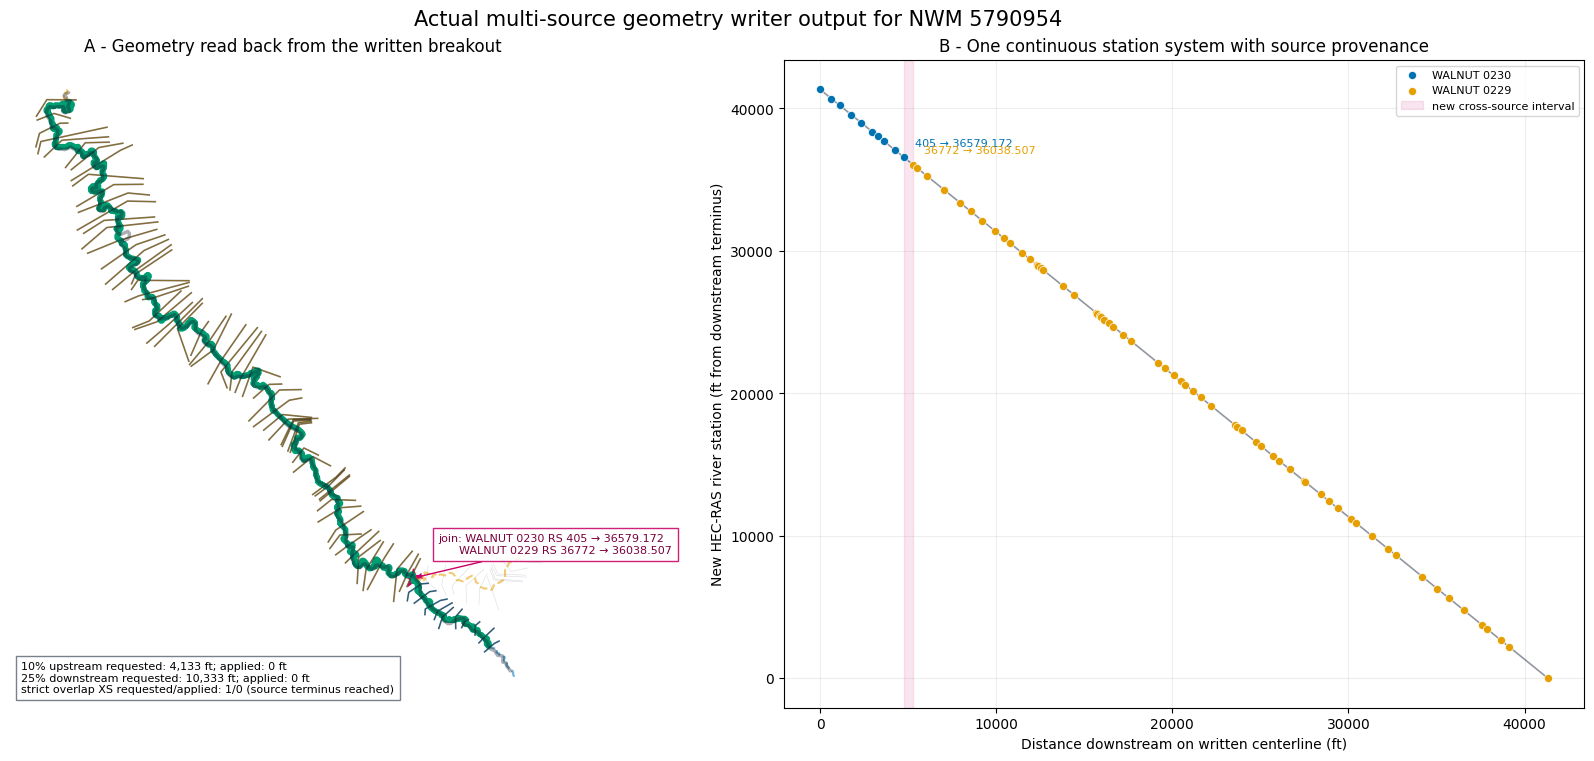

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\05_written_geometry_and_restationing.png


In [9]:
written_centerline = GeomParser.get_river_centerlines(assembled.geometry_file).geometry.iloc[0]
node_map = assembled.station_map_gdf.copy()
written_xs = node_map.loc[node_map["source_node_type"] == 1].copy()
strict_xs = written_xs.loc[written_xs["in_inundation_domain"]]
all_selected_source_xs = catalog.cross_sections_gdf.loc[
    catalog.cross_sections_gdf["reach_id"].isin(confirmed_reach_ids)
]
join_evidence = assembled.seams_gdf.iloc[0]
join_upstream = written_xs.loc[written_xs["is_join_upstream"]].iloc[0]
join_downstream = written_xs.loc[written_xs["is_join_downstream"]].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5), constrained_layout=True)
all_selected_source_xs.plot(ax=axes[0], color="#9CA3AF", linewidth=0.45, alpha=0.35)
for source_id in SOURCE_IDS:
    confirmed_centerlines.loc[
        confirmed_centerlines["geometry_id"] == source_id
    ].plot(ax=axes[0], color=colors[source_id], linewidth=1.5, linestyle="--", alpha=0.55)
    written_xs.loc[
        written_xs["source_geometry_id"] == source_id
    ].plot(ax=axes[0], color=colors[source_id], linewidth=0.85, alpha=0.75)
gpd.GeoSeries([written_centerline], crs=PROJECT_CRS).plot(
    ax=axes[0], color="#009E73", linewidth=4, label="written joined centerline"
)
strict_xs.plot(ax=axes[0], color="#111827", linewidth=1.25, alpha=0.45)
target_edge.plot(ax=axes[0], color="#111827", linewidth=2.5, alpha=0.35)
assembled.seams_gdf.plot(ax=axes[0], color="#CC0066", marker="*", markersize=180)
axes[0].annotate(
    f"join: {join_upstream.source_geometry_id} RS {join_upstream.source_station} → {join_upstream.destination_station}\n"
    f"      {join_downstream.source_geometry_id} RS {join_downstream.source_station} → {join_downstream.destination_station}",
    xy=(join_evidence.geometry.x, join_evidence.geometry.y), xytext=(18, 18),
    textcoords="offset points", arrowprops={"arrowstyle": "->", "color": "#CC0066"},
    fontsize=8, color="#7A003C", bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "#CC0066"},
)
axes[0].set_title("A - Geometry read back from the written breakout")
domain_attrs = assembled.station_map_gdf.attrs
axes[0].text(
    0.02, 0.02,
    f"10% upstream requested: {domain_attrs['upstream_buffer_distance']:,.0f} ft; applied: {domain_attrs['upstream_buffer_applied']:,.0f} ft\n"
    f"25% downstream requested: {domain_attrs['downstream_buffer_distance']:,.0f} ft; applied: {domain_attrs['downstream_buffer_applied']:,.0f} ft\n"
    f"strict overlap XS requested/applied: {domain_attrs['inundation_overlap_xs']}/{domain_attrs['inundation_overlap_xs_applied']} (source terminus reached)",
    transform=axes[0].transAxes, fontsize=8, va="bottom",
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#6B7280"},
)
axes[0].set_axis_off()

for source_id in SOURCE_IDS:
    frame = written_xs.loc[written_xs["source_geometry_id"] == source_id]
    axes[1].scatter(
        frame["centerline_measure"], frame["destination_station"].astype(float),
        s=34, color=colors[source_id], edgecolor="white", linewidth=0.5, label=source_id, zorder=3,
    )
axes[1].plot(
    written_xs["centerline_measure"], written_xs["destination_station"].astype(float),
    color="#374151", linewidth=1.2, alpha=0.55,
)
for row in (join_upstream, join_downstream):
    axes[1].annotate(
        f"{row.source_station} → {row.destination_station}",
        (row.centerline_measure, float(row.destination_station)),
        xytext=(8, 8), textcoords="offset points", fontsize=8, color=colors[row.source_geometry_id],
    )
axes[1].axvspan(
    join_upstream.centerline_measure, join_downstream.centerline_measure,
    color="#CC0066", alpha=0.10, label="new cross-source interval",
)
axes[1].set_xlabel("Distance downstream on written centerline (ft)")
axes[1].set_ylabel("New HEC-RAS river station (ft from downstream terminus)")
axes[1].set_title("B - One continuous station system with source provenance")
axes[1].grid(alpha=0.22)
axes[1].legend(fontsize=8)
fig.suptitle("Actual multi-source geometry writer output for NWM 5790954", fontsize=15)
figure_5 = ASSET_ROOT / "05_written_geometry_and_restationing.png"
fig.savefig(figure_5, dpi=180, bbox_inches="tight")
plt.show()
print(figure_5)


![Written multi-source geometry and continuous restationing](assets/236_multi_model_1d_breakout_planning/05_written_geometry_and_restationing.png)

## 9. Compile the provisional geometry and finalize flow-path policy

The provisional project is first computed through `RasCmdr`, which creates the
geometry HDF needed for a real RAS Mapper flow-path audit. Shorter station text
in compiled HDF tables is matched uniquely back to the writer's full-precision
station map. The audit clones the project, regenerates flow paths, and compares
all usable LOB/ROB intervals with their stored values.

The Texas source overbank lengths are not reproduced within 1%, so the final
writer uses `preserve_and_recompute_only_at_join_boundary`: source LOB/ROB
lengths remain unchanged, while only the new cross-model interval receives the
two clipped regenerated path lengths. The final model is then computed again.


In [10]:
provisional_compute = RasBreakout1D.run(
    assembled,
    verify=False,
    force_rerun=True,
)
provisional_geom_hdf = Path(f"{assembled.geometry_file}.hdf")
provisional_plan_hdf = Path(f"{assembled.plan_file}.hdf")
provisional_messages = HdfResultsPlan.get_compute_messages(provisional_plan_hdf)
assert "Complete Process" in provisional_messages

join_upstream = assembled.station_map_gdf.loc[
    assembled.station_map_gdf["is_join_upstream"]
].iloc[0]
join_downstream = assembled.station_map_gdf.loc[
    assembled.station_map_gdf["is_join_downstream"]
].iloc[0]
review_segments_path = RUN_ROOT / "join-0-flow-paths.parquet"
policy = RasGeometryCompute.assess_flow_path_policy(
    provisional_geom_hdf,
    tolerance_fraction=0.01,
    join_upstream_xs=(
        join_upstream.destination_river,
        join_upstream.destination_reach,
        join_upstream.destination_station,
    ),
    join_downstream_xs=(
        join_downstream.destination_river,
        join_downstream.destination_reach,
        join_downstream.destination_station,
    ),
    review_segments_path=review_segments_path,
    hecras_version=RAS_VERSION,
)
assert policy.recommended_policy == "preserve_and_recompute_only_at_join_boundary"
assert set(policy.join_segments_gdf["side"]) == {"left", "right"}

FINAL_ROOT = RUN_ROOT / "assembled_final"
final = RasBreakout1D.assemble_network_edge(
    source_models,
    catalog,
    plan,
    FINAL_ROOT,
    destination_name=f"NWM_{TARGET_EDGE_ID}_breakout",
    destination_river=f"NWM {TARGET_EDGE_ID}",
    destination_reach="Main",
    inundation_overlap_xs=1,
    flow_path_policy_results={0: policy},
)
assert final.reach_lengths_finalized
assert final.flow_path_policy == policy.recommended_policy

final_compute = RasBreakout1D.run(final, verify=False, force_rerun=True)
final_geom_hdf = Path(f"{final.geometry_file}.hdf")
final_plan_hdf = Path(f"{final.plan_file}.hdf")
final_messages = HdfResultsPlan.get_compute_messages(final_plan_hdf)
assert "Complete Process" in final_messages

final_channel_audit = RasGeometryCompute.audit_main_channel_lengths(
    final.geometry_file, tolerance_fraction=0.01
)
usable_final_channel = final_channel_audit.loc[~final_channel_audit["reach_end"]]
assert not usable_final_channel["main_channel_flagged"].any()

display(policy.reach_metrics_df)
display(policy.join_segments_gdf.drop(columns="geometry"))
display(final.seams_gdf.drop(columns="geometry"))
display(pd.DataFrame([{
    "provisional_compute": provisional_compute.success,
    "final_compute": final_compute.success,
    "recommended_policy": policy.recommended_policy,
    "main_channel_flagged_intervals": int(usable_final_channel["main_channel_flagged"].sum()),
    "max_main_channel_relative_error": usable_final_channel["relative_error_channel"].max(),
}]))
print(f"Final independent project: {final.project_file}")
print(f"Join review segments: {review_segments_path}")


2026-09-09 09:26:24 - ras_commander.hdf.HdfXsec - WARNING - No river flow paths found in geometry file


2026-09-09 09:26:27 - ras_commander.hdf.HdfBase - WARNING - Projection not found for NWM_5790954_breakout.g01.hdf; returned geospatial outputs will not have a CRS. Enable DEBUG for checked paths and RASMapper projection setup guidance.


2026-09-09 09:26:27 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\assembled_final\NWM_5790954_breakout.rasmap


2026-09-09 09:26:27 - ras_commander.RasBreakout1D - INFO - Assembled H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\assembled_final\NWM_5790954_breakout.prj from 2 source models with 72 retained cross sections


,River,Reach,source_flow_paths_present,source_flow_path_count,interval_count,overbank_match_count,overbank_match_fraction,max_relative_error_left,max_relative_error_right,stored_overbanks_differ_from_channel,main_channel_flagged_count,max_relative_error_channel,recommended_policy,reason_codes,tolerance_fraction
0,NWM 5790954,Main,False,0,71,9,0.126761,2.11844,0.765005,True,0,0.00077,preserve_and_recompute_only_at_join_boundary,"(REGENERATED_OVERBANK_LENGTH_MISMATCH, MISSING...",0.01


,River,Reach,upstream_rs,downstream_rs,side,flow_path_id,length
0,NWM 5790954,Main,36579.172,36038.507,left,0,333.471017
1,NWM 5790954,Main,36579.172,36038.507,right,1,524.647310


,edge_id,seam_index,upstream_geometry_id,downstream_geometry_id,join_method,connector_length,edge_measure,upstream_source_measure,downstream_source_measure,upstream_source_station,downstream_source_station,upstream_destination_station,downstream_destination_station,join_left_length,join_channel_length,join_right_length,length_policy
0,5790954,0,WALNUT 0230,WALNUT 0229,centerline_intersection,0.0,5205.799664,6853.731957,6300.56737,405,36772,36579.172,36038.507,333.471017,540.664972,524.64731,preserve_and_recompute_only_at_join_boundary


,provisional_compute,final_compute,recommended_policy,main_channel_flagged_intervals,max_main_channel_relative_error
0,True,True,preserve_and_recompute_only_at_join_boundary,0,0.000011


Final independent project: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\assembled_final\NWM_5790954_breakout.prj
Join review segments: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\join-0-flow-paths.parquet


## 10. Compute the original plans and isolate geometry diagnostics

A successful hydraulic computation does not by itself prove that geometry
diagnostics were introduced by the join. Both complete original plans are
therefore computed in isolated destination folders, leaving the FEMA source
folders untouched. Each exact retained source slice is also written and
computed independently, without a cross-model join.

Cross-section diagnostics are traced through `station_map_gdf` from final
destination station to source model and source station. A non-station edge-line
diagnostic is accepted as pre-existing only when the same diagnostic reproduces
in an independently computed retained source slice. Any unmatched or
join-adjacent diagnostic fails the assertions below and requires remediation.


In [11]:
source_diagnostics = {}
retained_diagnostics = {}
source_run_results = {}
retained_run_results = {}
model_paths = catalog.models_df.set_index("geometry_id")

for source_id in SOURCE_IDS:
    source_run = RUN_ROOT / f"original-{source_id.replace(' ', '-').lower()}"
    source_run_results[source_id] = RasCmdr.compute_plan(
        "01",
        ras_object=source_models[source_id],
        dest_folder=source_run,
        clear_geompre=True,
        force_rerun=True,
        verify=False,
    )
    source_geom_hdf = source_run / f"{source_id}.g01.hdf"
    source_plan_hdf = source_run / f"{source_id}.p01.hdf"
    assert "Complete Process" in HdfResultsPlan.get_compute_messages(source_plan_hdf)
    source_diagnostics[source_id] = RasGeometryCompute.validate_geometry(source_geom_hdf)

    retained_nodes = final.station_map_gdf.loc[
        (final.station_map_gdf["source_geometry_id"] == source_id)
        & (final.station_map_gdf["source_node_type"] == 1)
    ].copy()
    source_station_values = retained_nodes["source_station"].astype(float)
    first = retained_nodes.iloc[0]
    selection = RasBreakout1D.select_by_stations(
        Path(model_paths.loc[source_id, "geometry_path"]),
        river=first.source_river,
        reach=first.source_reach,
        upstream_station=source_station_values.max(),
        downstream_station=source_station_values.min(),
    )
    retained_root = RUN_ROOT / f"retained-{source_id.replace(' ', '-').lower()}"
    retained = RasBreakout1D.extract_selection(
        source_models[source_id],
        retained_root,
        selection,
        plan_number="01",
        destination_name=f"{source_id}_retained",
        boundary_mode="preserve",
    )
    retained_run_results[source_id] = RasBreakout1D.run(
        retained,
        verify=False,
        force_rerun=True,
    )
    retained_geom_hdf = Path(f"{retained.geometry_file}.hdf")
    retained_plan_hdf = Path(f"{retained.plan_file}.hdf")
    assert "Complete Process" in HdfResultsPlan.get_compute_messages(retained_plan_hdf)
    retained_diagnostics[source_id] = RasGeometryCompute.validate_geometry(retained_geom_hdf)

final_diagnostics = RasGeometryCompute.validate_geometry(final_geom_hdf)
xs_map = final.station_map_gdf.loc[
    final.station_map_gdf["source_node_type"] == 1
].copy()
xs_map["destination_station_value"] = xs_map["destination_station"].astype(float)


def diagnostic_key(row):
    return str(row.layer), str(row.message)


provenance_rows = []
for diagnostic in final_diagnostics.itertuples(index=False):
    source_id = None
    source_station = None
    destination_station = diagnostic.RS
    join_adjacent = False
    retained_match = False
    original_match = False

    if diagnostic.layer == "Cross Sections" and pd.notna(diagnostic.RS):
        candidates = xs_map.loc[
            (xs_map["destination_station_value"] - float(diagnostic.RS)).abs() < 0.011
        ]
        if len(candidates) == 1:
            mapped = candidates.iloc[0]
            source_id = mapped.source_geometry_id
            source_station = mapped.source_station
            join_adjacent = bool(mapped.is_join_upstream or mapped.is_join_downstream)
            original = source_diagnostics[source_id]
            retained_source = retained_diagnostics[source_id]
            original_match = bool((
                (original["layer"] == diagnostic.layer)
                & (original["message"] == diagnostic.message)
                & ((original["RS"].astype(float) - float(source_station)).abs() < 0.011)
            ).any())
            retained_match = bool((
                (retained_source["layer"] == diagnostic.layer)
                & (retained_source["message"] == diagnostic.message)
                & ((retained_source["RS"].astype(float) - float(source_station)).abs() < 0.011)
            ).any())
    else:
        for candidate_source in SOURCE_IDS:
            original = source_diagnostics[candidate_source]
            retained_source = retained_diagnostics[candidate_source]
            candidate_original_match = any(
                diagnostic_key(row) == diagnostic_key(diagnostic)
                for row in original.itertuples(index=False)
            )
            candidate_retained_match = any(
                diagnostic_key(row) == diagnostic_key(diagnostic)
                for row in retained_source.itertuples(index=False)
            )
            if candidate_retained_match:
                source_id = candidate_source
                original_match = candidate_original_match
                retained_match = True
                break

    origin = (
        "pre_existing_retained"
        if original_match and retained_match and not join_adjacent
        else "join_or_assembly_introduced"
    )
    provenance_rows.append({
        "severity": diagnostic.severity,
        "layer": diagnostic.layer,
        "destination_station": destination_station,
        "source_geometry_id": source_id,
        "source_station": source_station,
        "original_plan_match": original_match,
        "retained_slice_match": retained_match,
        "join_adjacent": join_adjacent,
        "origin": origin,
        "message": diagnostic.message,
    })

diagnostic_provenance = pd.DataFrame(provenance_rows)
assert not diagnostic_provenance.empty
assert diagnostic_provenance["origin"].eq("pre_existing_retained").all()
assert not diagnostic_provenance["join_adjacent"].any()
assert set(
    diagnostic_provenance.loc[
        diagnostic_provenance["layer"] == "Cross Sections", "source_station"
    ].astype(str)
) == {"4041", "28258", "27657", "26377", "22852", "734"}

display(diagnostic_provenance)
display(pd.DataFrame([{
    "original_plans_complete": all(result.success for result in source_run_results.values()),
    "retained_slices_complete": all(result.success for result in retained_run_results.values()),
    "final_plan_complete": final_compute.success,
    "final_diagnostic_count": len(final_diagnostics),
    "pre_existing_retained": int(diagnostic_provenance["origin"].eq("pre_existing_retained").sum()),
    "join_or_assembly_introduced": int(diagnostic_provenance["origin"].eq("join_or_assembly_introduced").sum()),
}]))


2026-09-09 09:26:33 - ras_commander.RasCmdr - INFO - Copied project folder to destination: original-walnut-0230


2026-09-09 09:26:33 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\original-walnut-0230\WALNUT 0230.rasmap


2026-09-09 09:26:33 - ras_commander.RasPrj - WARNING - Could not resolve project CRS for original-walnut-0230


2026-09-09 09:26:38 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\retained-walnut-0230\WALNUT 0230_retained.rasmap


2026-09-09 09:26:38 - ras_commander.RasBreakout1D - INFO - Created one-reach breakout H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\retained-walnut-0230\WALNUT 0230_retained.prj with 10 retained cross sections


...

2026-09-09 09:26:44 - ras_commander.RasPrj - WARNING - Could not resolve project CRS for original-walnut-0229


2026-09-09 09:26:49 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\retained-walnut-0229\WALNUT 0229_retained.rasmap


2026-09-09 09:26:49 - ras_commander.RasBreakout1D - INFO - Created one-reach breakout H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\runs\20260909_092616\retained-walnut-0229\WALNUT 0229_retained.prj with 62 retained cross sections


,severity,layer,destination_station,source_geometry_id,source_station,original_plan_match,retained_slice_match,join_adjacent,origin,message
0,ERROR,Cross Sections,40215.15,WALNUT 0230,4041,True,True,False,pre_existing_retained,XS intersects > 2 banklines
1,ERROR,Cross Sections,27523.74,WALNUT 0229,28258,True,True,False,pre_existing_retained,XS intersects > 2 banklines
2,ERROR,Cross Sections,26922.91,WALNUT 0229,27657,True,True,False,pre_existing_retained,XS intersects > 2 banklines
3,ERROR,Cross Sections,25642.77,WALNUT 0229,26377,True,True,False,pre_existing_retained,XS intersects > 2 banklines
4,ERROR,Cross Sections,22117.85,WALNUT 0229,22852,True,True,False,pre_existing_retained,XS intersects > 2 banklines
5,ERROR,Cross Sections,0,WALNUT 0229,734,True,True,False,pre_existing_retained,XS intersects > 2 banklines
6,ERROR,Edge Lines,NaN,WALNUT 0229,NaN,True,True,False,pre_existing_retained,Polyline has self intersections
7,WARNING,Edge line self intersections,NaN,WALNUT 0229,NaN,True,True,False,pre_existing_retained,This is a edge line self intersection point


,original_plans_complete,retained_slices_complete,final_plan_complete,final_diagnostic_count,pre_existing_retained,join_or_assembly_introduced
0,True,True,True,8,8,0


All eight final diagnostics are pre-existing retained-source findings. The six
cross-section messages map exactly to source stations `4041`, `28258`, `27657`,
`26377`, `22852`, and `734`. None is one of the two sections adjacent to the
join. The edge-line self-intersection and its warning reproduce in the retained
`WALNUT 0229` slice without any join, which isolates them from assembly logic.

## 11. Visual proof: diagnostics are separated from the join


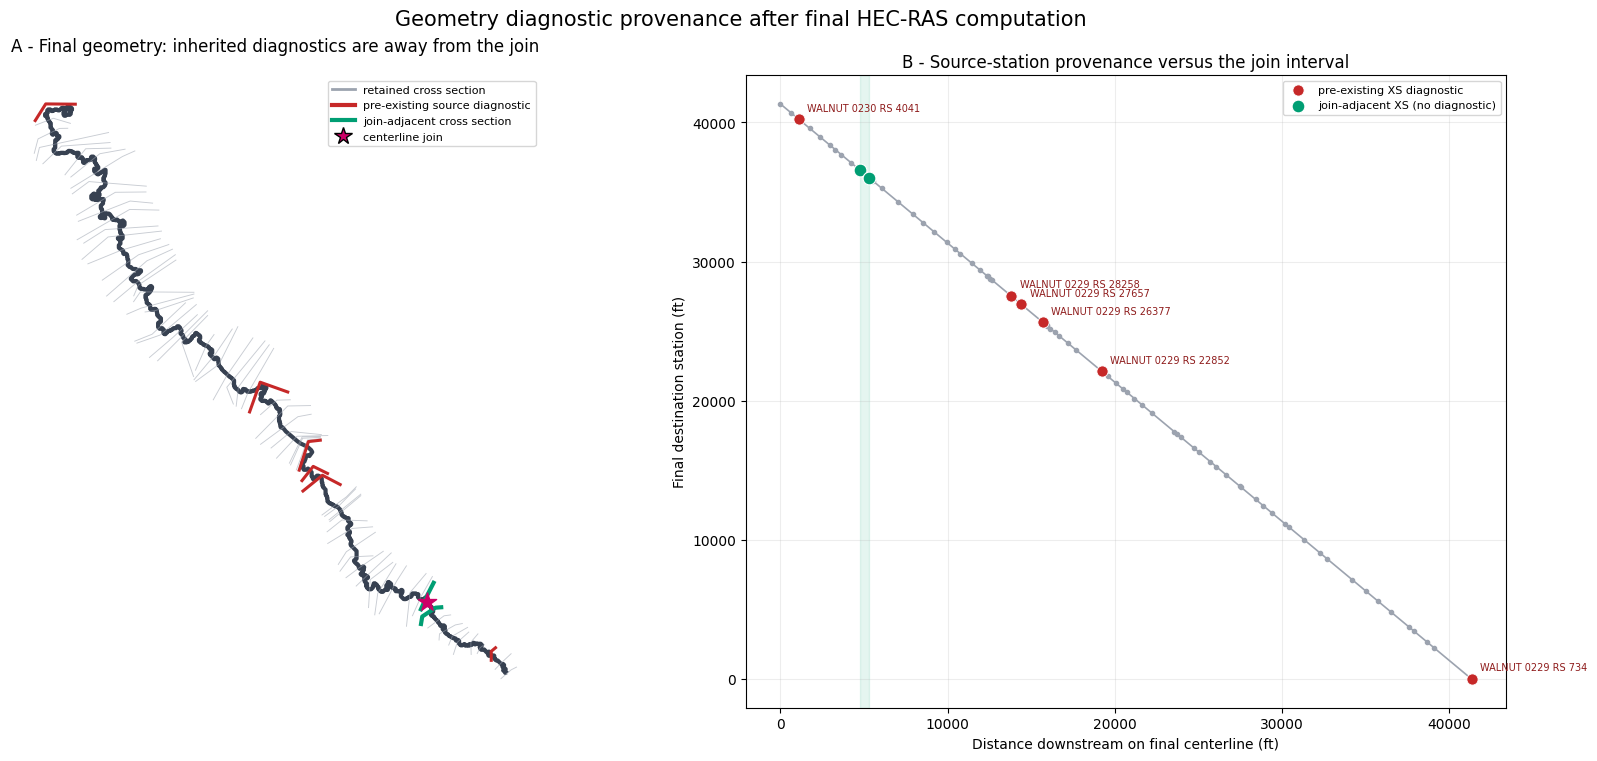

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\06_geometry_diagnostic_provenance.png


In [12]:
final_xs = final.station_map_gdf.loc[
    final.station_map_gdf["source_node_type"] == 1
].copy()
error_destinations = diagnostic_provenance.loc[
    diagnostic_provenance["layer"] == "Cross Sections", "destination_station"
].astype(float)
error_mask = final_xs["destination_station"].astype(float).apply(
    lambda value: bool(((error_destinations - value).abs() < 0.011).any())
)
error_xs = final_xs.loc[error_mask]
join_xs = final_xs.loc[final_xs["is_join_upstream"] | final_xs["is_join_downstream"]]
final_centerline = GeomParser.get_river_centerlines(final.geometry_file).geometry.iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5), constrained_layout=True)
gpd.GeoSeries([final_centerline], crs=PROJECT_CRS).plot(
    ax=axes[0], color="#374151", linewidth=3
)
final_xs.plot(ax=axes[0], color="#9CA3AF", linewidth=0.65, alpha=0.55)
error_xs.plot(ax=axes[0], color="#C62828", linewidth=2.2, zorder=5)
join_xs.plot(ax=axes[0], color="#009E73", linewidth=3.0, zorder=6)
final.seams_gdf.plot(
    ax=axes[0], color="#CC0066", marker="*", markersize=190, zorder=7
)
axes[0].set_axis_off()
axes[0].set_title("A - Final geometry: inherited diagnostics are away from the join")
axes[0].legend(handles=[
    Line2D([0], [0], color="#9CA3AF", linewidth=2, label="retained cross section"),
    Line2D([0], [0], color="#C62828", linewidth=3, label="pre-existing source diagnostic"),
    Line2D([0], [0], color="#009E73", linewidth=3, label="join-adjacent cross section"),
    Line2D([0], [0], marker="*", color="none", markerfacecolor="#CC0066", markersize=13, label="centerline join"),
], loc="best", fontsize=8)

axes[1].plot(
    final_xs["centerline_measure"],
    final_xs["destination_station"].astype(float),
    color="#9CA3AF", linewidth=1.2, marker="o", markersize=3,
)
axes[1].scatter(
    error_xs["centerline_measure"],
    error_xs["destination_station"].astype(float),
    color="#C62828", edgecolor="white", linewidth=0.6, s=65, zorder=5,
    label="pre-existing XS diagnostic",
)
axes[1].scatter(
    join_xs["centerline_measure"],
    join_xs["destination_station"].astype(float),
    color="#009E73", edgecolor="white", linewidth=0.8, s=85, zorder=6,
    label="join-adjacent XS (no diagnostic)",
)
for row in error_xs.itertuples(index=False):
    axes[1].annotate(
        f"{row.source_geometry_id} RS {row.source_station}",
        (row.centerline_measure, float(row.destination_station)),
        xytext=(6, 6), textcoords="offset points", fontsize=7, color="#8E1B1B",
    )
join_min = join_xs["centerline_measure"].min()
join_max = join_xs["centerline_measure"].max()
axes[1].axvspan(join_min, join_max, color="#009E73", alpha=0.10)
axes[1].set_xlabel("Distance downstream on final centerline (ft)")
axes[1].set_ylabel("Final destination station (ft)")
axes[1].set_title("B - Source-station provenance versus the join interval")
axes[1].grid(alpha=0.22)
axes[1].legend(fontsize=8)
fig.suptitle("Geometry diagnostic provenance after final HEC-RAS computation", fontsize=15)
figure_6 = ASSET_ROOT / "06_geometry_diagnostic_provenance.png"
fig.savefig(figure_6, dpi=180, bbox_inches="tight")
plt.show()
print(figure_6)


![Pre-existing source geometry diagnostics separated from the join](assets/236_multi_model_1d_breakout_planning/06_geometry_diagnostic_provenance.png)

## 12. Visual proof: only the join overbank lengths are recomputed


C:\Users\bill\AppData\Local\Temp\ipykernel_24876\1341996651.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  join_focus = join_xs.geometry.unary_union.convex_hull.buffer(900.0)


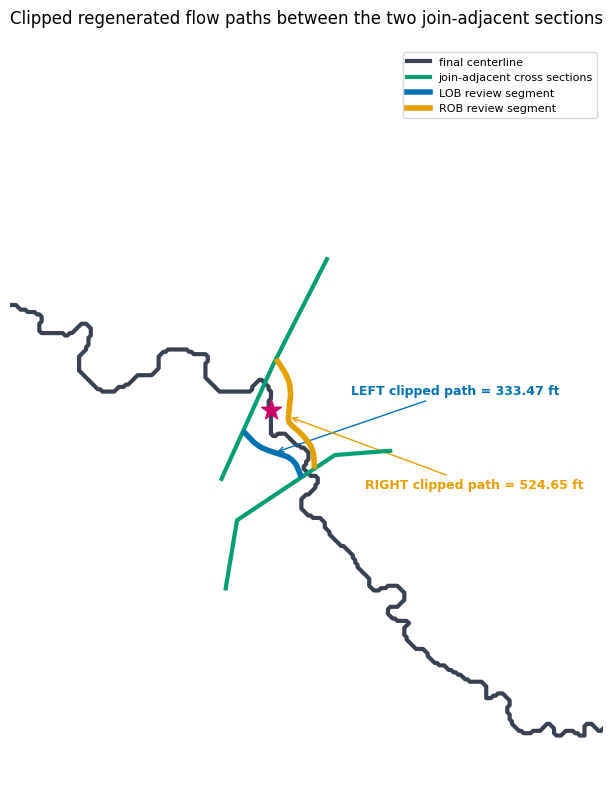

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\07_join_flow_path_evidence.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
join_focus = join_xs.geometry.unary_union.convex_hull.buffer(900.0)
gpd.GeoSeries([final_centerline], crs=PROJECT_CRS).plot(
    ax=ax, color="#374151", linewidth=3, label="final river centerline"
)
join_xs.plot(ax=ax, color="#009E73", linewidth=3.0, zorder=5)
for side, color in (("left", "#0072B2"), ("right", "#E69F00")):
    segment = policy.join_segments_gdf.loc[policy.join_segments_gdf["side"] == side]
    segment.plot(ax=ax, color=color, linewidth=4.0, zorder=6)
    row = segment.iloc[0]
    midpoint = row.geometry.interpolate(0.5, normalized=True)
    ax.annotate(
        f"{side.upper()} clipped path = {row.length:,.2f} ft",
        (midpoint.x, midpoint.y), xytext=(55, 42 if side == "left" else -52),
        textcoords="offset points", arrowprops={"arrowstyle": "->", "color": color},
        color=color, fontsize=9, fontweight="bold",
    )
final.seams_gdf.plot(
    ax=ax, color="#CC0066", marker="*", markersize=220, zorder=7
)
xmin, ymin, xmax, ymax = join_focus.bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Clipped regenerated flow paths between the two join-adjacent sections")
ax.legend(handles=[
    Line2D([0], [0], color="#374151", linewidth=3, label="final centerline"),
    Line2D([0], [0], color="#009E73", linewidth=3, label="join-adjacent cross sections"),
    Line2D([0], [0], color="#0072B2", linewidth=4, label="LOB review segment"),
    Line2D([0], [0], color="#E69F00", linewidth=4, label="ROB review segment"),
], loc="best", fontsize=8)
figure_7 = ASSET_ROOT / "07_join_flow_path_evidence.png"
fig.savefig(figure_7, dpi=180, bbox_inches="tight")
plt.show()
print(figure_7)


![Clipped regenerated flow-path evidence at the new join](assets/236_multi_model_1d_breakout_planning/07_join_flow_path_evidence.png)

## 13. Visual hydraulic comparison with both original plans

Geometry provenance does not show whether the joined model creates a hydraulic
discontinuity. The final plan's retained-section results are therefore mapped
back to both original plans using the source/destination station crosswalk.
The figure shows the full 100-year profile, a join-focused profile view, every
profile's WSE residual along the combined reach, and the maximum absolute WSE
change by profile. Flow changes are checked numerically as well.


,profile,retained_xs,mean_wse_delta,mean_absolute_wse_delta,maximum_absolute_wse_delta,maximum_absolute_velocity_delta,maximum_absolute_flow_delta,max_at_source,max_at_source_station,max_at_destination_station
0,10-year,72,-0.0015,0.0035,0.1523,0.1274,0.0000,WALNUT 0230,405,36579.17
1,100-year,72,0.0070,0.0131,0.6433,0.6925,0.0000,WALNUT 0230,405,36579.17
2,1pct_min,72,-0.0009,0.0024,0.0865,0.0877,0.0000,WALNUT 0230,405,36579.17
3,1pct_plu,72,0.0265,0.0272,1.7802,1.3430,0.0000,WALNUT 0230,405,36579.17
4,25-year,72,0.0019,0.0045,0.1845,0.2048,0.0000,WALNUT 0230,405,36579.17
5,50-year,72,0.0033,0.0087,0.3769,0.4678,0.0000,WALNUT 0230,405,36579.17
6,500-year,72,0.0148,0.0196,1.1801,1.0543,0.0000,WALNUT 0230,405,36579.17


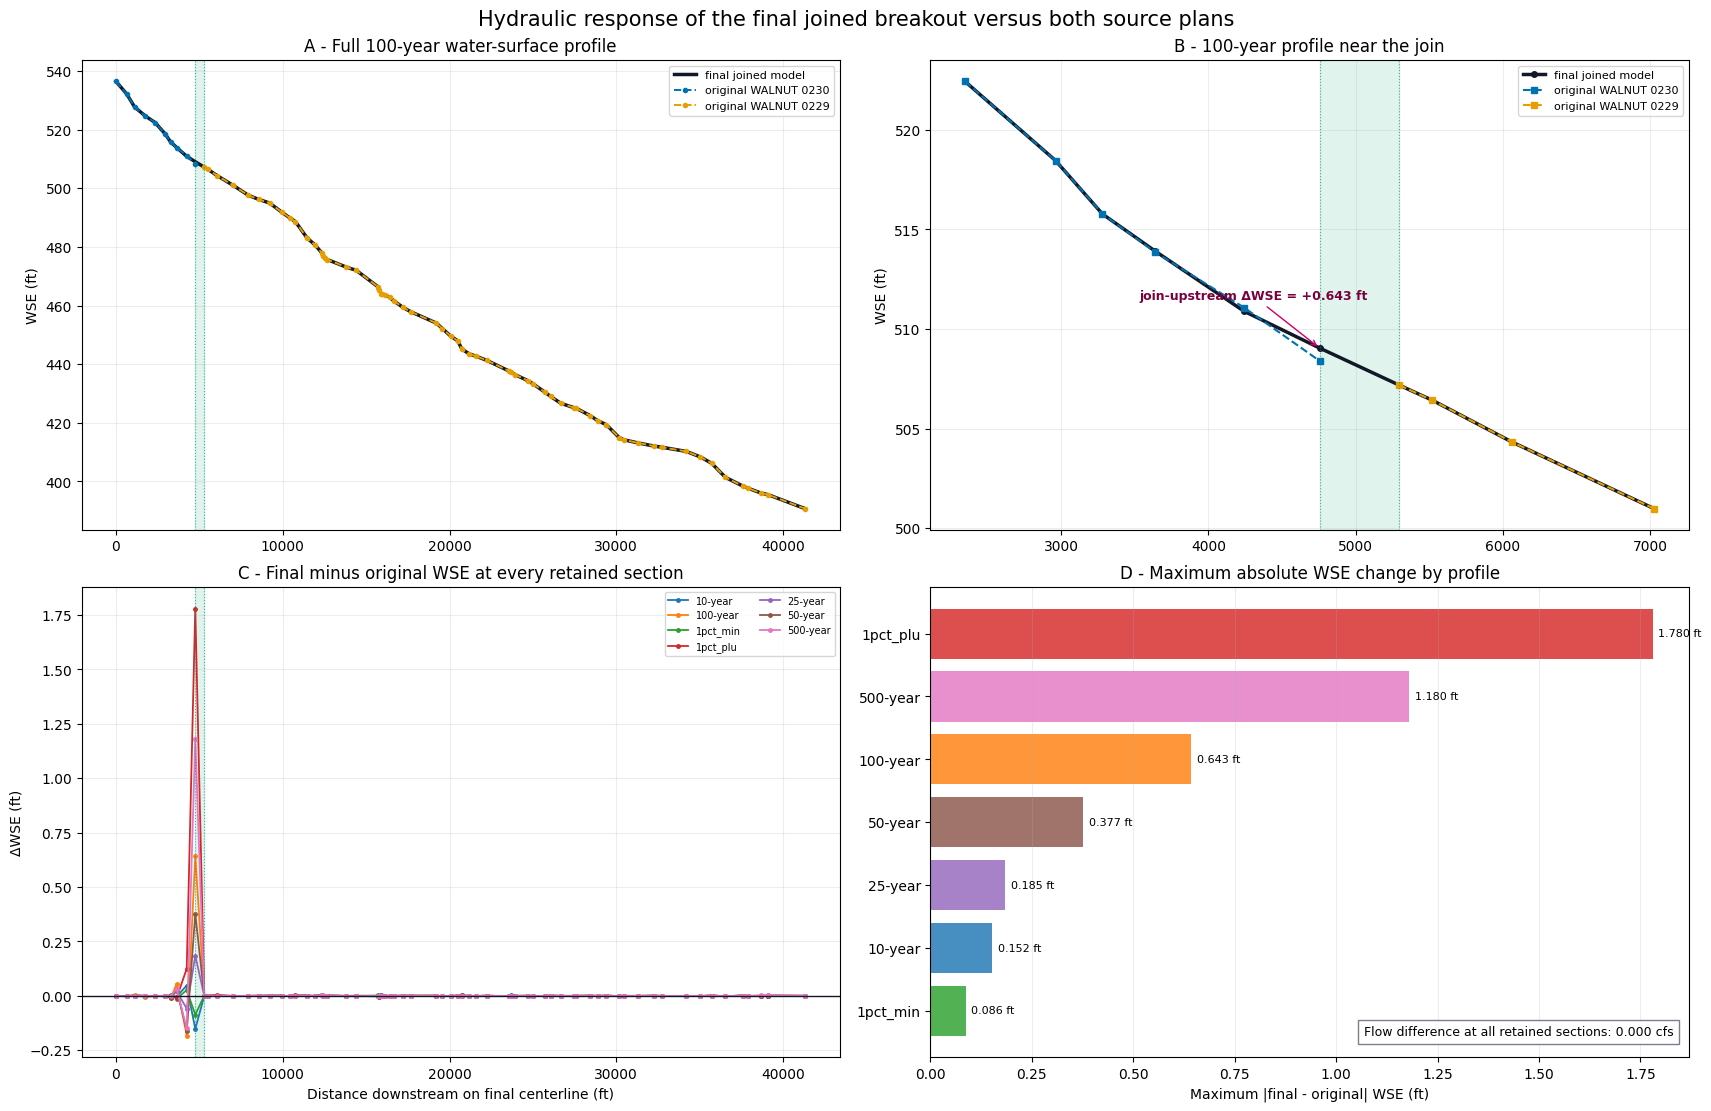

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\08_source_vs_final_hydraulics.png


In [14]:
final_results = HdfResultsPlan.get_steady_results(final_plan_hdf).copy()
final_results["destination_station_value"] = final_results["node_id"].astype(float)
result_station_map = final_xs[[
    "source_geometry_id", "source_station", "destination_station",
    "centerline_measure", "is_join_upstream", "is_join_downstream",
]].copy()
result_station_map["destination_station_value"] = result_station_map[
    "destination_station"
].astype(float)
result_station_map["source_station_value"] = result_station_map[
    "source_station"
].astype(float)

mapped_final = pd.merge_asof(
    final_results.sort_values("destination_station_value"),
    result_station_map.sort_values("destination_station_value")[
        [
            "destination_station_value", "source_geometry_id",
            "source_station_value", "centerline_measure",
            "is_join_upstream", "is_join_downstream",
        ]
    ],
    on="destination_station_value",
    direction="nearest",
    tolerance=0.011,
)
assert mapped_final["source_geometry_id"].notna().all()

source_result_frames = []
for source_id in SOURCE_IDS:
    source_plan_hdf = (
        RUN_ROOT / f"original-{source_id.replace(' ', '-').lower()}"
        / f"{source_id}.p01.hdf"
    )
    source_results = HdfResultsPlan.get_steady_results(source_plan_hdf).copy()
    source_results["source_geometry_id"] = source_id
    source_results["source_station_value"] = source_results["node_id"].astype(float)
    source_result_frames.append(source_results)
source_results = pd.concat(source_result_frames, ignore_index=True)

hydraulic_comparison = mapped_final.merge(
    source_results[[
        "source_geometry_id", "source_station_value", "profile",
        "wsel", "velocity", "flow", "energy",
    ]],
    on=["source_geometry_id", "source_station_value", "profile"],
    suffixes=("_final", "_source"),
    validate="many_to_one",
)
hydraulic_comparison["wse_delta"] = (
    hydraulic_comparison["wsel_final"] - hydraulic_comparison["wsel_source"]
)
hydraulic_comparison["velocity_delta"] = (
    hydraulic_comparison["velocity_final"] - hydraulic_comparison["velocity_source"]
)
hydraulic_comparison["flow_delta"] = (
    hydraulic_comparison["flow_final"] - hydraulic_comparison["flow_source"]
)
hydraulic_comparison["abs_wse_delta"] = hydraulic_comparison["wse_delta"].abs()

hydraulic_summary = hydraulic_comparison.groupby("profile", as_index=False).agg(
    retained_xs=("source_station_value", "size"),
    mean_wse_delta=("wse_delta", "mean"),
    mean_absolute_wse_delta=("abs_wse_delta", "mean"),
    maximum_absolute_wse_delta=("abs_wse_delta", "max"),
    maximum_absolute_velocity_delta=("velocity_delta", lambda values: values.abs().max()),
    maximum_absolute_flow_delta=("flow_delta", lambda values: values.abs().max()),
)
maximum_rows = hydraulic_comparison.loc[
    hydraulic_comparison.groupby("profile")["abs_wse_delta"].idxmax(),
    ["profile", "source_geometry_id", "source_station_value", "destination_station_value"],
].rename(columns={
    "source_geometry_id": "max_at_source",
    "source_station_value": "max_at_source_station",
    "destination_station_value": "max_at_destination_station",
})
hydraulic_summary = hydraulic_summary.merge(maximum_rows, on="profile")

assert len(hydraulic_comparison) == 72 * 7
assert hydraulic_summary["retained_xs"].eq(72).all()
assert hydraulic_summary["maximum_absolute_flow_delta"].max() < 1.0e-6
display(hydraulic_summary.style.format({
    "mean_wse_delta": "{:.4f}",
    "mean_absolute_wse_delta": "{:.4f}",
    "maximum_absolute_wse_delta": "{:.4f}",
    "maximum_absolute_velocity_delta": "{:.4f}",
    "maximum_absolute_flow_delta": "{:.4f}",
    "max_at_source_station": "{:.0f}",
    "max_at_destination_station": "{:.2f}",
}))

comparison_profile = "100-year"
profile_comparison = hydraulic_comparison.loc[
    hydraulic_comparison["profile"] == comparison_profile
].sort_values("centerline_measure")
join_start = join_xs["centerline_measure"].min()
join_end = join_xs["centerline_measure"].max()
profile_colors = dict(zip(
    hydraulic_summary["profile"], plt.cm.tab10.colors[: len(hydraulic_summary)]
))

fig, axes = plt.subplots(2, 2, figsize=(17, 11), constrained_layout=True)
axes[0, 0].plot(
    profile_comparison["centerline_measure"], profile_comparison["wsel_final"],
    color="#111827", linewidth=2.5, label="final joined model",
)
for source_id in SOURCE_IDS:
    frame = profile_comparison.loc[
        profile_comparison["source_geometry_id"] == source_id
    ]
    axes[0, 0].plot(
        frame["centerline_measure"], frame["wsel_source"],
        color=colors[source_id], linestyle="--", marker="o", markersize=3,
        linewidth=1.4, label=f"original {source_id}",
    )
axes[0, 0].axvspan(join_start, join_end, color="#009E73", alpha=0.12)
axes[0, 0].set_title(f"A - Full {comparison_profile} water-surface profile")
axes[0, 0].set_ylabel("WSE (ft)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.22)

join_window = profile_comparison.loc[
    profile_comparison["centerline_measure"].between(join_start - 2500, join_end + 2500)
]
axes[0, 1].plot(
    join_window["centerline_measure"], join_window["wsel_final"],
    color="#111827", linewidth=2.5, marker="o", markersize=4,
    label="final joined model",
)
for source_id in SOURCE_IDS:
    frame = join_window.loc[join_window["source_geometry_id"] == source_id]
    axes[0, 1].plot(
        frame["centerline_measure"], frame["wsel_source"],
        color=colors[source_id], linestyle="--", marker="s", markersize=4,
        linewidth=1.5, label=f"original {source_id}",
    )
axes[0, 1].axvspan(join_start, join_end, color="#009E73", alpha=0.12)
join_upstream_result = join_window.loc[join_window["is_join_upstream"]].iloc[0]
axes[0, 1].annotate(
    f"join-upstream ΔWSE = {join_upstream_result.wse_delta:+.3f} ft",
    (join_upstream_result.centerline_measure, join_upstream_result.wsel_final),
    xytext=(-130, 35), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#CC0066"},
    color="#7A003C", fontsize=9, fontweight="bold",
)
axes[0, 1].set_title(f"B - {comparison_profile} profile near the join")
axes[0, 1].set_ylabel("WSE (ft)")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.22)

for profile, frame in hydraulic_comparison.groupby("profile"):
    frame = frame.sort_values("centerline_measure")
    axes[1, 0].plot(
        frame["centerline_measure"], frame["wse_delta"],
        linewidth=1.3, marker="o", markersize=2.5,
        color=profile_colors[profile], label=profile,
    )
axes[1, 0].axhline(0.0, color="#111827", linewidth=1.0)
axes[1, 0].axvspan(join_start, join_end, color="#009E73", alpha=0.12)
axes[1, 0].set_title("C - Final minus original WSE at every retained section")
axes[1, 0].set_xlabel("Distance downstream on final centerline (ft)")
axes[1, 0].set_ylabel("ΔWSE (ft)")
axes[1, 0].legend(fontsize=7, ncol=2)
axes[1, 0].grid(alpha=0.22)

summary_plot = hydraulic_summary.sort_values("maximum_absolute_wse_delta")
bars = axes[1, 1].barh(
    summary_plot["profile"], summary_plot["maximum_absolute_wse_delta"],
    color=[profile_colors[name] for name in summary_plot["profile"]], alpha=0.82,
)
axes[1, 1].bar_label(bars, fmt="%.3f ft", padding=4, fontsize=8)
axes[1, 1].set_title("D - Maximum absolute WSE change by profile")
axes[1, 1].set_xlabel("Maximum |final - original| WSE (ft)")
axes[1, 1].grid(axis="x", alpha=0.22)
axes[1, 1].text(
    0.98, 0.04, "Flow difference at all retained sections: 0.000 cfs",
    transform=axes[1, 1].transAxes, ha="right", va="bottom", fontsize=9,
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#6B7280"},
)

for ax in (axes[0, 0], axes[0, 1], axes[1, 0]):
    ax.axvline(join_start, color="#009E73", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.axvline(join_end, color="#009E73", linestyle=":", linewidth=0.8, alpha=0.7)
fig.suptitle("Hydraulic response of the final joined breakout versus both source plans", fontsize=15)
figure_8 = ASSET_ROOT / "08_source_vs_final_hydraulics.png"
fig.savefig(figure_8, dpi=180, bbox_inches="tight")
plt.show()
print(figure_8)


![Source-versus-final hydraulic profile comparison](assets/236_multi_model_1d_breakout_planning/08_source_vs_final_hydraulics.png)

## Result

The final independent project contains 72 cross sections: all 10 owned sections
from `WALNUT 0230` and 62 non-overlapping downstream sections from `WALNUT 0229`.
Fourteen downstream-source sections upstream of the accepted join are excluded.
Destination stations run continuously from 41,332.705 ft to 0, and the new join
channel interval is 540.665 ft.

The final overbank policy preserves every source interval and writes only the
new join as 333.471 ft LOB and 524.647 ft ROB. Both original plans, both retained
single-source slices, the provisional joined plan, and the final joined plan
reach `Complete Process` in HEC-RAS 7.0.1. The final main-channel audit has zero
intervals outside 1%.

All seven flow profiles preserve source flow exactly at all 72 retained cross
sections. Water-surface changes are concentrated at the source handoff: the
100-year maximum is 0.643 ft at the upstream join section, and the largest
change across all profiles is 1.780 ft for `1pct_plu` at that same section.
Those values are exposed for H&H review rather than treated as an automatic
pass/fail threshold; they demonstrate why the computational overlap and
join-focused comparison are necessary.

Six bankline-crossing diagnostics and one edge-line self-intersection plus its
warning remain. The source/destination crosswalk and independently computed
retained slices prove all eight are pre-existing source findings, not join or
restationing regressions; none is join-adjacent. They are therefore recorded for
review rather than silently altered by the breakout writer.
